<a href="https://colab.research.google.com/github/wbandabarragan/Bootcamp2025/blob/main/CursoA_Semana1/Clase_02/Clase_2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# N-dimensional Plotting

In this lecture we will revise some of the main plotting packages with a guided astrophysical example of a self-gravitating parcel of gas.

The packages are:

- Matpotlib (https://matplotlib.org)
- Plotly (https://plotly.com)
- YT (https://yt-project.org)


## 1. Matplotlib: 1D density profile of Isothermal Self-Gravitating Gas Slab


We start from the system of equations describing hydrostatic equilibrium and self-gravity in 1D (vertical direction $z$):

#### Poisson Equation:
$$\frac{d^2 \Phi}{dz^2} = 4\pi G \rho(z)$$

#### Hydrostatic Equilibrium:
$$\frac{dP}{dz} = -\rho(z) \frac{d\Phi}{dz}$$

#### Isothermal Equation of State:
$$P = \rho c_s^2$$

#### Solution to the above equations:

The density profile is:

$$\rho(z) = \rho_0 \, \text{sech}^2 \left( \frac{z}{H} \right)$$

where: $H = \frac{c_s}{\sqrt{2\pi G \rho_0}}$

This describes the vertical equilibrium of a self-gravitating, isothermal slab.

Some examples include:

- The mid-plane of a galactic disc.
  
- A dense molecular sheet in the the interstellar medium (ISM).

- Gas layers in the interstellar medium (ISM).

#### Reference: https://ui.adsabs.harvard.edu/abs/1942ApJ....95..329S

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Scipy constants
import scipy.constants as const

In [3]:
G = const.G * 1e6 * 1e-3 # gravitational constant in cgs

In [4]:
cs = 2e4        # sound speed in cm/s (~0.2 km/s typical for cold ISM)
rho0 = 1e-18    # central density in g/cm^3 (typical dense molecular cloud)


In [5]:
# Scale height
H = cs / np.sqrt(2 * np.pi * G * rho0)

# z range (from -4H to 4H)
z = np.linspace(-4*H, 4*H, 500)
rho = rho0 * (1 / np.cosh(z / H))**2

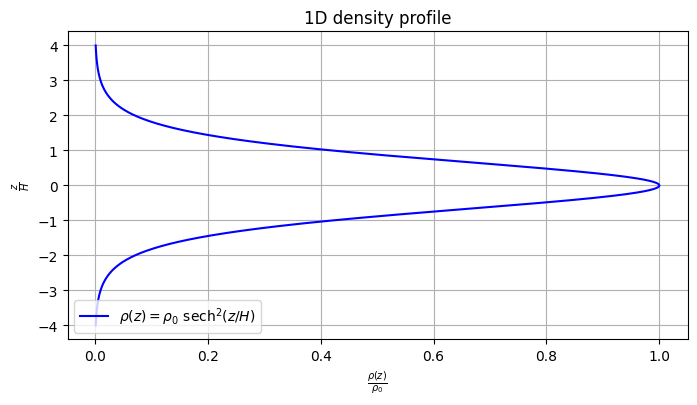

In [6]:
# Plotting
plt.figure(figsize=(8, 4))

plt.plot(rho / rho0,z / H, color='blue', label=r'$\rho(z) = \rho_0 \ \mathrm{sech}^2(z/H)$')

plt.xlabel(r'$\frac{\rho(z)}{\rho_0}$')
plt.ylabel(r'$\frac{z}{H}$')

plt.title("1D density profile")
plt.grid(True)

plt.legend(loc=3)

plt.show()

### Export figure in GDrive



In [7]:
# empezamos cargando en drive, como estoy en local no necesito
#from google.colab import drive
#drive.mount('/content/drive')

In [8]:
# Navigate to your desired Google Drive folder (create if it doesn't exist)
%cd /content/drive/MyDrive/Bootcamp2025/

[Errno 2] No such file or directory: '/content/drive/MyDrive/Bootcamp2025/'
/home/and-torr/Documents/git_workspace/Bootcamp2025/CursoA_Semana1/Clase_02


In [9]:
#!mkdir -p images

!ls -ltr

total 14168
-rw-rw-r-- 1 and-torr and-torr 5790670 jul  8 17:13 Clase_2g.ipynb
drwxrwxr-x 2 and-torr and-torr    4096 jul  8 20:24 Output
drwxrwxr-x 2 and-torr and-torr   20480 jul  8 20:55 csv
-rw-rw-r-- 1 and-torr and-torr  710011 jul  8 22:31 Clase_2b.ipynb
drwxrwxr-x 2 and-torr and-torr    4096 jul  8 22:38 images
-rw-rw-r-- 1 and-torr and-torr 6775391 jul 10 14:35 Clase_2c.ipynb
-rw-rw-r-- 1 and-torr and-torr  968385 jul 10 19:02 Clase_2d.ipynb
-rw-rw-r-- 1 and-torr and-torr  224314 jul 13 00:25 Clase_2a.ipynb


In [10]:
!ls

Clase_2a.ipynb	Clase_2c.ipynb	Clase_2g.ipynb	images
Clase_2b.ipynb	Clase_2d.ipynb	csv		Output


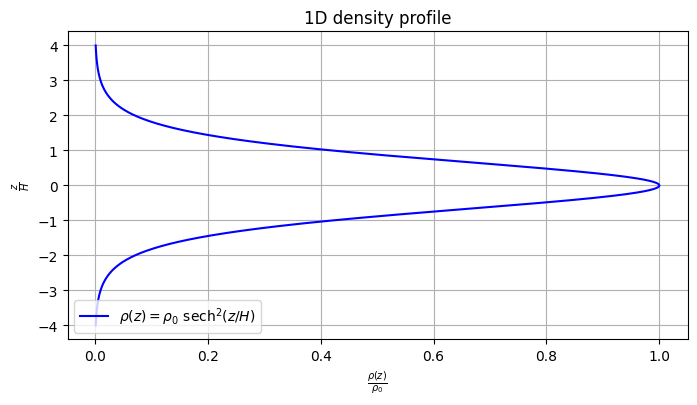

In [11]:
# Plotting
plt.figure(figsize=(8, 4))

plt.plot(rho / rho0,z / H, color='blue', label=r'$\rho(z) = \rho_0 \ \mathrm{sech}^2(z/H)$')

plt.xlabel(r'$\frac{\rho(z)}{\rho_0}$')
plt.ylabel(r'$\frac{z}{H}$')

plt.title("1D density profile")
plt.grid(True)

plt.legend(loc=3)

#plt.show()

plt.savefig("./images/1d_density.png")

## 2. Matplotlib: 2D density profile of Isothermal Self-Gravitating Gas Slab (Cylindrical Symmetry)

In 2D cylindrical symmetry (e.g., interstellar filaments), the equilibrium density profile is:

$$\rho(r) = \frac{\rho0}{\left(1 + \frac{r^2}{8 H^2} \right)^2}$$

Where:

- $\rho(r)$ is the gas density as a function of cylindrical radius $r$,
- $\rho0$ is the central density,
- $H = \frac{c_s}{\sqrt{4\pi G \rho0}}$ is the scale height (depends on sound speed $c_s$ and gravity $G$).

#### Reference: https://ui.adsabs.harvard.edu/abs/1964ApJ...140.1056O

In [12]:
# 2D Scale height
H = cs / np.sqrt(4 * np.pi * G * rho0)

# 2D grid setup
Rmax = 3 * H
N = 600

In [13]:
# Meshgrid creation
x = np.linspace(-Rmax, Rmax, N)
y = np.linspace(-Rmax, Rmax, N)

print(x.shape) #verificar forma del vector x, 

# ahora creamos la grilla donde se llenará la información
x_2d, y_2d = np.meshgrid(x, y)

# debe tener la misma forma de la grilla creada
print(f"La forma del vector x es {x_2d.shape} y la forma del vector y es {y_2d.shape}")

# calculamos el radio
R = np.sqrt(x_2d**2 + y_2d**2)

# Ostriker solution for 2D filament
rho = rho0 / (1 + R**2 / (8 * H**2))**2
print(f"la forma del vector solucion para cada R(x,y) es {rho.shape}") # tiene la forma de todos los vectores

# Normalize for plotting
rho_norm = rho / np.max(rho) #Para plotear se suele normalizar con el objetivo de 
                                # poder observar mejor las representaciones en timelines
                                # multiples variables en un mismo rango para observar su comportamiento
                                

(600,)
La forma del vector x es (600, 600) y la forma del vector y es (600, 600)
la forma del vector solucion para cada R(x,y) es (600, 600)


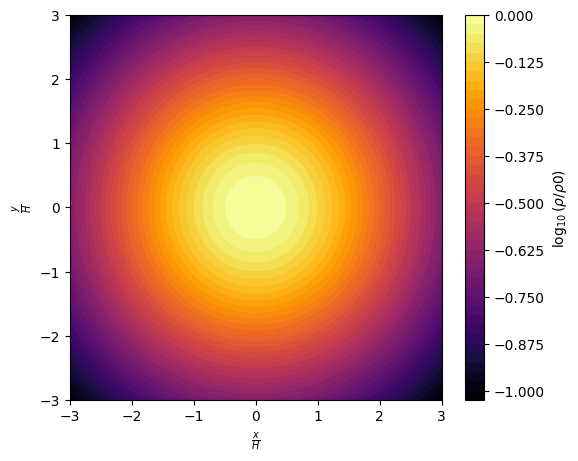

In [14]:

# Plot creamos el entorno
plt.figure(figsize=(6, 5))

# creamos el gráfico.
plt.contourf(x_2d/H, y_2d/H, np.log10(rho_norm), levels=50, cmap='inferno')

# creamos la barra de colores
cbar = plt.colorbar(label=r'$\log_{10}(\rho / \rho0)$')

# decoramos
plt.xlabel(r'$\frac{x}{H}$')
plt.ylabel(r'$\frac{y}{H}$')

#mostrar
plt.show()


In [15]:
from matplotlib import cm 

# Plot
# plt.figure(figsize=(6, 5))

#plt.contourf(x_2d/H, y_2d/H, np.log10(rho_norm), levels=50, cmap='inferno')

#ax = plt.axes(projection = "3d")

#ax.contour3D(x_2d/H, y_2d/H, np.log10(rho_norm), 500, cmap=cm.coolwarm)

#cbar = plt.colorbar()

#plt.xlabel(r'$\frac{x}{H}$')
#plt.ylabel(r'$\frac{y}{H}$')


#plt.savefig("./images/2d_density.png")


## 3. Plotly: 3D interactive plotting

- Plotly is an open-source graphing library used to create interactive visualisations directly in web browsers.

- It can be integrated with jupyter notebookssupports.

- Plotly is highly versatile, with APIs available in Python, R, JavaScript.

#### Website: https://plotly.com

### Example: 3D spherical profile of Isothermal Self-Gravitating Slab (approximation)

A commonly used analytic approximation to the solution of the isothermal Lane-Emden equation in 3D is given by the **modified Hubble profile**:

$$
\rho(r) = \frac{\rho_0}{\left(1 + \frac{r^2}{r_c^2} \right)^{3/2}}
$$

This expression provides a good fit (within 7% accuracy) to the numerical isothermal sphere solution for $r \lesssim 4 r_c$, where $\rho_0$ is the central density and $r_c$ is a characteristic core radius.

#### Reference: https://ui.adsabs.harvard.edu/abs/2008gady.book.....B


In [16]:
# Importing library
import plotly.graph_objects as go

In [17]:
# Fix parameters
rc = 1.0
N = 128  # Resolution of the grid
L = 6.0

# Axes
x = y = z = np.linspace(-L, L, N)

# 3D grid
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Radial coordinate
R = np.sqrt(X**2 + Y**2 + Z**2)

# Density field (approximation to Lane-Emden equation)
rho = rho0 / (1 + (R / rc)**2)**1.5

In [18]:

# Create 3D isosurface plot
# fig = go.Figure(data=go.Isosurface(x=X.flatten(),y=Y.flatten(),z=Z.flatten(),\
#                                    value=rho.flatten(),isomin=1.e-22,isomax=1.e-19,surface_count=4,\
#                                     caps=dict(x_show=False, y_show=False, z_show=False),colorscale='Viridis',))

# fig.update_layout(scene=dict(xaxis_title='x',yaxis_title='y',zaxis_title='z'),\
#                   title='3D Isothermal Sphere',margin=dict(l=0, r=0, b=0, t=30))

# fig.show()


### Clipping 3D volumes with Plotly

In [19]:
# Create a boolean mask for the desired region (e.g., x <= 0, y <= 0, z <= 0)
mask = (Z <= 0)

# Apply the mask to X, Y, Z, and rho
X_octant = X[mask]
Y_octant = Y[mask]
Z_octant = Z[mask]
rho_octant = rho[mask]

# Create 3D isosurface plot using the filtered data
# caps is used to render the cut faces at x=0, y=0, z=0
#fig = go.Figure(data=go.Isosurface(x=X_octant.flatten(),y=Y_octant.flatten(),z=Z_octant.flatten(),value=rho_octant.flatten(),\
#      isomin=5.0e-21,isomax=5.0e-19,surface_count=8,caps=dict(x_show=True, y_show=True, z_show=True),colorscale='Viridis'))

#fig.update_layout(scene=dict(xaxis_title='x',yaxis_title='y',zaxis_title='z',\
#                  camera=dict(eye=dict(x=1.8, y=1.8, z=1.8))),title='Clipped 3D Isothermal Sphere',
#                  margin=dict(l=0, r=0, b=0, t=30))
#fig.show()